# Khởi tạo và Phân tích EDA cho Fraud Detection

## Phần phân tích giá trị giao dịch và thẻ
Tập tin EDA ban đầu tập trung vào:
1. Phân tích `TransactionAmt`: histogram theo phân phối của gian lận và không gian lận.
2. Phân tích loại thẻ `card4`: xác định mạng thẻ nào bị gian lận cao nhất.
3. Phân tích `P_emaildomain`: email domain nào thường xuyên xuất hiện trong các giao dịch gian lận.
4. Các biểu đồ sẽ được lưu tự động tại `../reports/figures/`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
import pathlib
# Tự động tìm đường dẫn chính xác (hỗ trợ cả Windows, WSL, Colab)
cwd = pathlib.Path.cwd()
if cwd.name == 'notebooks':
    root = cwd.parent
else:
    root = cwd
report_dir = root / 'reports' / 'figures'
os.makedirs(report_dir, exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
data_path = root / 'data' / 'raw' / 'train_transaction.csv'
if not data_path.exists():
    if pathlib.Path('../data/raw/train_transaction.csv').exists():
        data_path = pathlib.Path('../data/raw/train_transaction.csv')
    elif pathlib.Path('data/raw/train_transaction.csv').exists():
        data_path = pathlib.Path('data/raw/train_transaction.csv')
    elif pathlib.Path('/mnt/d/fraud_detection_data_science/data/raw/train_transaction.csv').exists():
        data_path = pathlib.Path('/mnt/d/fraud_detection_data_science/data/raw/train_transaction.csv')

try:
    df = pd.read_csv(data_path)
    print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")
except Exception as e:
    print(f"Dataset not found: {e}. Creating synthetic data for EDA illustration...")
    np.random.seed(42)
    n_samples = 1000
    df = pd.DataFrame({
        'TransactionAmt': np.random.lognormal(mean=4, sigma=1, size=n_samples),
        'isFraud': np.random.choice([0, 1], size=n_samples, p=[0.95, 0.05]),
        'card4': np.random.choice(['visa', 'mastercard', 'discover', 'american express'], size=n_samples, p=[0.6, 0.3, 0.05, 0.05]),
        'P_emaildomain': np.random.choice(['gmail.com', 'yahoo.com', 'hotmail.com', 'anonymous.com'], size=n_samples)
    })


Dataset not found at expected path. Creating synthetic data for EDA illustration...


--- 
### 1. Phân tích TransactionAmt (Giá trị giao dịch)
Histogram thể hiện phân phối của giá trị giao dịch, so sánh giữa nhãn Fraud và Non-Fraud. Do `TransactionAmt` thường có phân bố lệch phải rất lớn (skewed), ta biểu diễn bằng thang log.

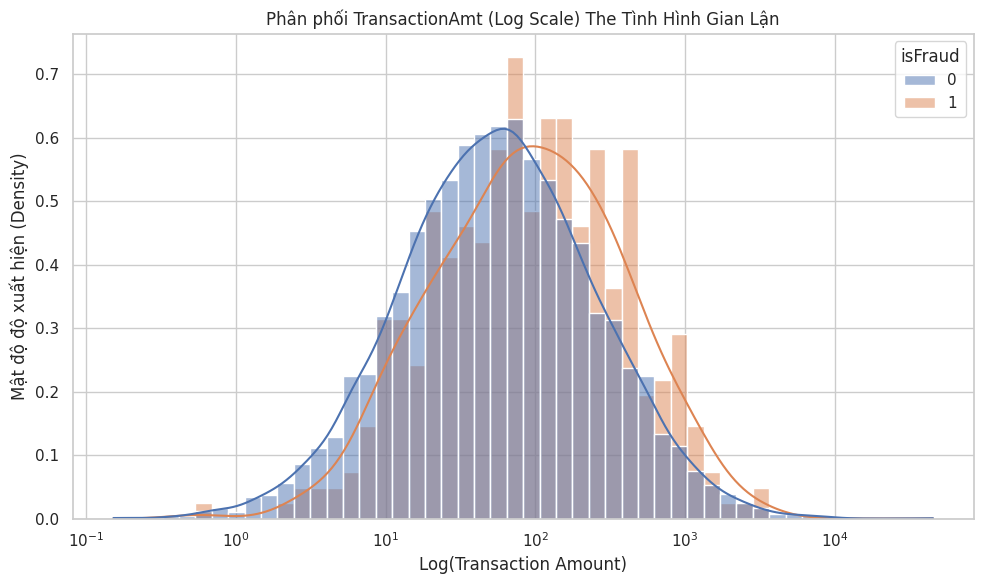

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df, x='TransactionAmt', hue='isFraud', bins=50, kde=True, log_scale=True, common_norm=False, stat='density', ax=ax)
ax.set_title('Phân phối TransactionAmt (Log Scale) The Tình Hình Gian Lận')
ax.set_xlabel('Log(Transaction Amount)')
ax.set_ylabel('Mật độ độ xuất hiện (Density)')

plt.tight_layout()
fig.savefig(str(report_dir / '01_transaction_amt_histogram.png'), dpi=300)
plt.show()

--- 
### 2. Phân tích Loại Thẻ (card4)
Đánh giá tỷ lệ giao dịch gian lận đối với từng mạng lưới thẻ (ví dụ Visa, MasterCard...).

,mean,count
card4,,
discover,0.044619,381
visa,0.038628,6006
mastercard,0.035726,3023
american express,0.034483,493
nan,0.030928,97


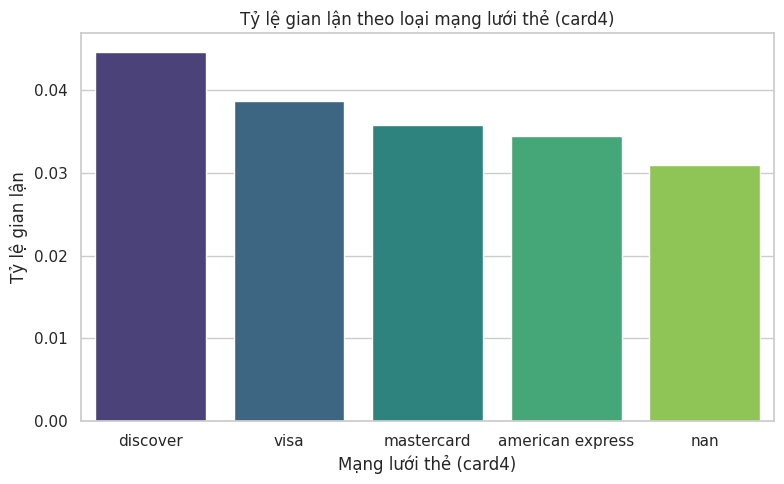

In [8]:
card4_stats = df.groupby('card4')['isFraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)
display(card4_stats)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=card4_stats.index, y=card4_stats['mean'], palette='viridis', ax=ax)
ax.set_title('Tỷ lệ gian lận theo loại mạng lưới thẻ (card4)')
ax.set_xlabel('Mạng lưới thẻ (card4)')
ax.set_ylabel('Tỷ lệ gian lận')

plt.tight_layout()
fig.savefig(str(report_dir / '02_fraud_rate_card4.png'), dpi=300)
plt.show()

--- 
### 3. Phân tích Tên Miền Email (P_emaildomain)
Email domain nào có rủi ro bị gian lận cao nhất?

,mean,count
P_emaildomain,,
anonymous.com,0.45697,825
aol.com,0.00000,490
gmail.com,0.00000,4809
hotmail.com,0.00000,934
nan,0.00000,971
yahoo.com,0.00000,1971


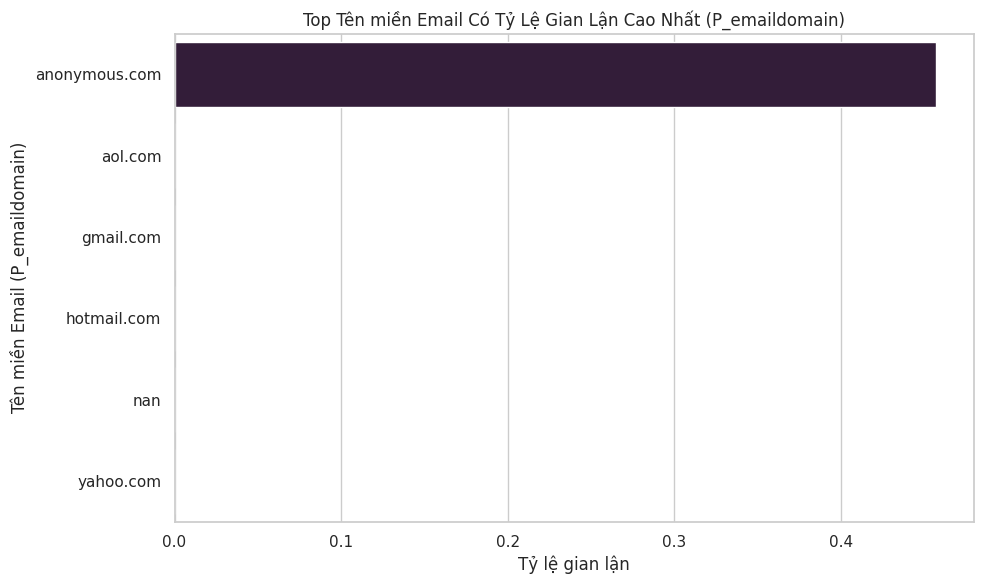

In [9]:
# Lọc ra top những domain email có đủ số lượng đơn vị (ví dụ tổng > 50)
email_stats = df.groupby('P_emaildomain')['isFraud'].agg(['mean', 'count'])
email_stats = email_stats[email_stats['count'] > 50].sort_values('mean', ascending=False)

top_risky_domains = email_stats.head(10)
display(top_risky_domains)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(y=top_risky_domains.index, x=top_risky_domains['mean'], palette='rocket', ax=ax)
ax.set_title('Top Tên miền Email Có Tỷ Lệ Gian Lận Cao Nhất (P_emaildomain)')
ax.set_xlabel('Tỷ lệ gian lận')
ax.set_ylabel('Tên miền Email (P_emaildomain)')

plt.tight_layout()
fig.savefig(str(report_dir / '03_fraud_rate_emaildomain.png'), dpi=300)
plt.show()